In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from collections import Counter

In [ ]:
from sympy import symbols, lambdify, I, conjugate, exp, diff, re, im, expand_complex, expand, simplify, sin, cos, integrate, sqrt,sign

In [ ]:
from scipy.optimize import minimize

In [ ]:
def coef3(recomp,imcomp,nmax):
    """This is to symbolically check the arrays.
    """
    Rx = []
    Ix = []

    n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))
    for k in np.arange(nmax + 1):
      if k == 0:
        for i in n:
          for j in np.arange(nmax + 1):
            if j != 0 or i >= 0:
              Rx.append(symbols(f"{recomp}_{k}{i}{j}",real = True))
              Ix.append(symbols(f"{imcomp}_{k}{i}{j}",real = True))
      else:
        for i in n:
          for j in n:
            Rx.append(symbols(f"{recomp}_{k}{i}{j}",real = True))
            Ix.append(symbols(f"{imcomp}_{k}{i}{j}",real = True))

    return Rx+Ix[1:]

In [ ]:
def factors(tup,comp,L):
  """comp is given as either [1,1] or [i,-i] depending on whether we are taking
  a derivative wrt the real part (A) or the imaginary part(B). Values in comp are
  the prefactors we get after taking the derivative. We treat the cases where a
  coefficients associated vector has a zero as a second component.
  """
  if tup < L:
    s = comp[0]
  else:
    s = comp[1]

  return s

In [ ]:
def comb_three(allcomb,N):
  """Similar to the first part of 'combinations', takes in all possible lists of 4 integers
  and the required N to produce the derivative terms. We require the sum of all elements
  to be not 0, but equal to minus the provided N.
  """

  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == -N:
      perm = list(set(itertools.permutations(allcomb[i],3)))
      for j in perm:
        list1.append(list(j))
  return list1

In [ ]:
def B4xyz(com,fac,C,indx):
  """Calculation of the 4th order terms that are not mixed (e.g. mx^4).
  Arrays must be arranged in such a way so that the components of each vector
  determine whether we consider a coefficient or its complex conjugate.
  C: An array of length 3. First element is a flat array in case the sign of the second component
  is 0. The proceeding matrices contain elements in the form of A + iB and A - iB respectively.
  com: indices for the 4th order terms.
  fac: combinatorial factors.
  """

  a = []
  for i in range(len(com)):
    b = 1
    for j in range(4):
      b *= C[indx.index(com[i][j])]
    a.append(b)

  c = a*np.array(fac)

  #ad = sum(c)

  return c #expand(Add(*a))

In [ ]:
def b4xyz(com,fac,C,comp,indx):
  """Calculation of the derivatives of the 4th order non-mixed terms.
  """
  L = int(len(indx) + 1)/2
  a = []
  for i in range(len(com)):
    b = factors(indx.index(com[i][0]),comp,L)
    for k in range(1,4):
      b *= C[indx.index(com[i][k])]
    a.append(b)

  c = a*np.array(fac)

  #ad = sum(c)

  return c #expand(Add(*a))

In [ ]:

def B2xyz(com, fac, C1, C2,indx):
  """Calculation of the 4th order terms that are mixed (e.g. mx^2my^2).
  That is why C1 and C2 contain coefficients of different magnetization components.
  """

  a = []
  for i in range(len(com)):
    b = 1
    for j in range(2):
      b *= C1[indx.index(com[i][j])]
    for k in range(2,4):
      b *= C2[indx.index(com[i][k])]

    a.append(np.prod(b))
  c = a*np.array(fac)

  #ad = sum(c)

  return c#ad

In [ ]:
def b2xyz(com, fac, C1, C2,comp,indx):
  """Calculation of the derivatives of the 4th order mixed terms.
  """
  a = []
  L = int(len(indx) + 1)/2
  for i in range(len(com)):
    b = factors(indx.index(com[i][0]),comp,L)*C1[indx.index(com[i][1])]
    for k in range(2,4):
      b *= C2[indx.index(com[i][k])]
    a.append(b)

  c = a*np.array(fac)

  #ad = sum(c)

  return c #ad

In [ ]:
def comb_lists3(cr1, cr2, cr3, cor):
  """Lists are combined in groups of three and only after finding the distinct
  combinations, the fourth elements are added in order to find the combinatorial
  factors.
  cr1, cr2, cr3 are the lists whose elements sum up to minus the given input for a
  single coordinate in reciprocal space.
  """

  comb_list4b = []
  comb_list2b = []
  for a in cr1:
      for b in cr2:
        for c in cr3:
          z = list(zip(a,b,c))
          comb_list4b.append(tuple(sorted(z)))
          comb_list2b.append(tuple(z[:1]+sorted(z[1:]))) #order the last two separately from the first element

  pos_comb4b = list(set(comb_list4b))
  pos_comb2b = list(set(comb_list2b))

  pc4b = []
  pc2b = []

  for el in pos_comb4b:
    pc4b.append(tuple(cor+list(el)))
    #adding the indices of the coefficient which we take the derivative with respect to

  for l in pos_comb2b:
    pc2b.append(tuple(cor+list(l)))

  return pc4b, pc2b

In [ ]:
def combinations3(nmax):
  """Takes in the integer bounds and produces lists for all distinct combinations
  of the indices that occur in the fourth order terms, as well as their combinatorial factors.
  """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,4)) #generate a list of 4 integers between -nmax and nmax

  #if the sum of integers within a list is 0 add all of its permutations to list1
  list1 = []
  for i in range(len(allcomb)):
    if sum(allcomb[i]) == 0:
      perm = list(set(itertools.permutations(allcomb[i],4)))
      for j in perm:
        list1.append(list(j))


  comb_list1 = []
  comb_list2 = []
  for a in list1:
    for b in list1:
      for c in list1:
        z = list(zip(a,b,c)) #combine the lists into 4 vectors with 2 components
        comb_list1.append(tuple(sorted(z))) #ordering the vectors
        comb_list2.append(tuple(sorted(z[:2])+sorted(z[2:])))
      #ordering the first two elements and the last two separately for the mixed 4th order terms

  pos_comb1 = list(set(comb_list1)) #select all the distinct elements
  pos_comb2 = list(set(comb_list2))
  comb_fac1 = []
  comb_fac2 = []

  #count the distinct permutations of an element to find the combinatorial factors
  for i in range(len(pos_comb1)):
    comb_fac1.append(len(set(list(itertools.permutations(pos_comb1[i])))))

  for j in range(len(pos_comb2)):
    comb_fac2.append(len(set(list(itertools.permutations(pos_comb2[j][2:]))))*len(set(list(itertools.permutations(pos_comb2[j][:2])))))
  return pos_comb1, comb_fac1, pos_comb2, comb_fac2

In [ ]:
def combinations_der3(x,nmax):
  """This produces the indices for the derivatives of the fourth order terms and
  their corresponding combinatorial factors.
  Supply x = [(a,b,c)] """

  n = np.arange(-nmax, nmax + 1, 1)
  allcomb = list(itertools.combinations_with_replacement(n,3)) #this time lists contain 3 elements
  ind = [x[0][0],x[0][1],x[0][2],-x[0][0],-x[0][1],-x[0][2]]
  #we need the vector and its inversion to demand complex conjugates are not treated separately

  coord = []
  for i in ind:
    coord.append(comb_three(allcomb, i))


  #derivative wrt the coefficient characterized by x and the complex conjugate of that term
  pc4b1, pc2b1 = comb_lists3(coord[0],coord[1],coord[2],[(x[0][0],x[0][1],x[0][2])])
  pc4b2, pc2b2 = comb_lists3(coord[3],coord[4],coord[5],[(-x[0][0],-x[0][1],-x[0][2])])

  comb_fac4b = []
  comb_fac2b = []

  pc4 = list(set(sorted(pc4b1 + pc4b2)))
  pc2 = list(set(pc2b1 + pc2b2))


  prefac4b = []
  prefac2b = []

  for i in range(len(pc4)): #combinatorial factors
    comb_fac4b.append(len(set(list(itertools.permutations(pc4[i])))))
    prefac4b.append(pc4[i].count(pc4[i][0]))


  for i in range(len(pc2)): #combinatorial factors for the mixed terms
    comb_fac2b.append(len(set(list(itertools.permutations(pc2[i][:2]))))*len(set(list(itertools.permutations(pc2[i][2:])))))
    prefac2b.append(pc2[i][:2].count(pc2[i][0]))


  cf4 = np.array(prefac4b) * np.array(comb_fac4b)
  cf2 = np.array(prefac2b) * np.array(comb_fac2b)

  return pc4, cf4, pc2, cf2

In [ ]:
def indexes3(nmax):
  n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))
  indices = []
  ind2 = []
  for k in np.arange(nmax + 1):
    if k == 0:
      for i in n:
        for j in np.arange(nmax + 1):
          if j != 0 or i >= 0:
            indices.append((k,i,j))
            ind2.append((-k,-i,-j))
    else:
      for i in n:
        for j in n:
          indices.append((k,i,j))
          ind2.append((-k,-i,-j))

  return indices, ind2


In [ ]:
def energy3(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):

  indx_pos, indx_neg = indexes3(nmax)
  indx = indx_pos + indx_neg[1:]
  arx, ary, arz = np.split(parameters[9:],3) #parameters[9:]
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posy, Negy = Ay + 1j*By, Ay - 1j*By
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Y4 = np.concatenate((Posy,Negy[1:])); Z4 = np.concatenate((Posz,Negz[1:]))


  SxSx = 2*Posx*Negx
  SxSx[0] = SxSx[0]/2
  SySy = 2*Posy*Negy
  SySy[0] = SySy[0]/2
  SzSz = 2*Posz*Negz
  SzSz[0] = SzSz[0]/2
  SxSy = Posx*Negy + Posy*Negx
  SxSy[0] = SxSy[0]/2
  SySz = Posy*Negz + Posz*Negy
  SySz[0] = SySz[0]/2
  SzSx = Posz*Negx + Posx*Negz
  SzSx[0] = SzSx[0]/2
  #SqS-q terms

  S4x = B4xyz(com3[0],com3[1],X4,indx)
  S4y = B4xyz(com3[0],com3[1],Y4,indx)
  S4z = B4xyz(com3[0],com3[1],Z4,indx)

  S2xy = B2xyz(com3[2],com3[3],X4,Y4,indx)
  S2yz = B2xyz(com3[2],com3[3],Y4,Z4,indx)
  S2zx = B2xyz(com3[2],com3[3],Z4,X4,indx)

  indx_pos = np.array(indx_pos)
  p1 = indx_pos[:,:1].reshape(-1)
  p2 = indx_pos[:,1:2].reshape(-1)
  p3 = indx_pos[:,2:].reshape(-1)

  qx = p1*parameters[0] + p2*parameters[3] + p3*parameters[6]
  qy = p1*parameters[1] + p2*parameters[4] + p3*parameters[7]
  qz = p1*parameters[2] + p2*parameters[5] + p3*parameters[8]

  exchange = (alpha1*(qx**2 + qy**2 + qz**2)**2 - J*(qx**2 + qy**2 + qz**2))*(SxSx + SySy + SzSz)
  SI_anisotropy = K*sum(S4x + S4y + S4z)
  ex4 = alpha2*(qx**4 + qy**4 + qz**4)*(SxSx + SySy + SzSz)
  anis2 = alpha3*(qx**2*SxSx + qy**2*SySy + qz**2*SzSz + 2*(qx*qy*SxSy + qy*qz*SySz + qz*qx*SzSx))
  anis2mix = alpha4*((qy**2 + qz**2)*SxSx + (qx**2 + qz**2)*SySy + (qx**2 + qy**2)*SzSz)

  Energy = (lamb*(sum(S4x + S4y + S4z) + 2*sum(S2xy + S2yz + S2zx) - 2 * sum(SxSx + SySy + SzSz) + 1) +
  a_l * (T - 1)*sum(SxSx + SySy + SzSz) + b_l * (sum(S4x + S4y + S4z) + 2*sum(S2xy + S2yz + S2zx)) +
  sum(exchange + ex4 + anis2 + anis2mix) + SI_anisotropy)

  return np.real(Energy)

In [ ]:
def derivatives3(indices,parameters, comp,  nmax, J, K, alpha1, alpha2, alpha3, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):
  """derivatives of energy wrt the Fourier coefficients. The derivative for the
  coefficient associated with (0,0) is treated differently since it has no imaginary part"""

  in_pos, in_neg = indexes3(nmax)
  indx = in_pos + in_neg[1:]
  arx, ary, arz = np.split(parameters[9:],3) #parameters[9:]
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posy, Negy = Ay + 1j*By, Ay - 1j*By
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz
  X4 = np.concatenate((Posx,Negx[1:])); Y4 = np.concatenate((Posy,Negy[1:])); Z4 = np.concatenate((Posz,Negz[1:]))

  #indx_pos = np.array(indx_pos)
  p1 = np.array(in_pos)[:,:1].reshape(-1)
  p2 = np.array(in_pos)[:,1:2].reshape(-1)
  p3 = np.array(in_pos)[:,2:].reshape(-1)

  qx = p1*parameters[0] + p2*parameters[3] + p3*parameters[6]
  qy = p1*parameters[1] + p2*parameters[4] + p3*parameters[7]
  qz = p1*parameters[2] + p2*parameters[5] + p3*parameters[8]

  dEx = []
  dEy = []
  dEz = []
  for i in range(len(indices)):

    indX = in_pos.index(indices[i])
    Cod = cod3[indX]
    S4x = b4xyz(Cod[0], Cod[1],X4,comp,indx)
    S4y = b4xyz(Cod[0], Cod[1],Y4,comp,indx)
    S4z = b4xyz(Cod[0], Cod[1],Z4,comp,indx)

    S2xy = b2xyz(Cod[2], Cod[3],X4, Y4,comp,indx)
    S2xz = b2xyz(Cod[2], Cod[3],X4, Z4,comp,indx)
    S2yx = b2xyz(Cod[2], Cod[3],Y4, X4,comp,indx)
    S2yz = b2xyz(Cod[2], Cod[3],Y4, Z4,comp,indx)
    S2zx = b2xyz(Cod[2], Cod[3],Z4, X4,comp,indx)
    S2zy = b2xyz(Cod[2], Cod[3],Z4, Y4,comp,indx)

    qX = qx[indX]
    qY = qy[indX]
    qZ = qz[indX]

    dSxSx = 2.0*comp[1]*Posx[indX] + 2.0*comp[0]*Negx[indX]
    dSySy = 2.0*comp[1]*Posy[indX] + 2.0*comp[0]*Negy[indX]
    dSzSz = 2.0*comp[1]*Posz[indX] + 2.0*comp[0]*Negz[indX]

    if indX == 0:
      dSxSx = dSxSx/2
      dSySy = dSySy/2
      dSzSz = dSzSz/2

    dEx.append(lamb*(sum(S4x) + 2*sum(S2xy + S2xz) - 2*dSxSx) + K*sum(S4x) +
      (alpha1*(qX**2 + qY**2 + qZ**2)**2 - J*(qX**2 + qY**2 + qZ**2))*dSxSx +
      alpha2*dSxSx*(qX**4 + qY**4 + qZ**4) +
      alpha3*(qX**2*dSxSx + 2*(qX*qY*0.5*dSySy + qZ*qX*0.5*dSzSz)) +
      alpha4*(qY**2 + qZ**2)*dSxSx
      + a_l*(T - 1)*dSxSx + b_l*(sum(S4x) + 2*sum(S2xy + S2xz)))


    dEy.append(lamb*(sum(S4y) + 2*sum(S2yx + S2yz) - 2*dSySy) + K*sum(S4y) +
      (alpha1*(qX**2 + qY**2 + qZ**2)**2 - J*(qX**2 + qY**2 + qZ**2))*dSySy +
      alpha2*dSySy*(qX**4 + qY**4 + qZ**4) +
      alpha3*(qY**2*dSySy + 2*(qX*qY*0.5*dSxSx + qZ*qY*0.5*dSzSz)) +
      alpha4*(qX**2 + qZ**2)*dSySy
      + a_l*(T - 1)*dSySy + b_l*(sum(S4y) + 2*sum(S2yx + S2yz)))

    dEz.append(lamb*(sum(S4z) + 2*sum(S2zy + S2zx) - 2*dSzSz)  + K*sum(S4z) +
      (alpha1*(qX**2 + qY**2 + qZ**2)**2 - J*(qX**2 + qY**2 + qZ**2))*dSzSz +
      alpha2*dSzSz*(qX**4 + qY**4 + qZ**4) +
      alpha3*(qZ**2*dSzSz + 2*(qX*qZ*0.5*dSxSx + qZ*qY*0.5*dSySy)) +
      alpha4*(qX**2 + qY**2)*dSzSz
      + a_l*(T - 1)*dSzSz + b_l*(sum(S4z) + 2*sum(S2zy + S2zx)))

  return np.array(dEx), np.array(dEy), np.array(dEz)

In [ ]:
def der_3q(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):
  indx_pos, indx_neg = indexes3(nmax)
  indx_pos = np.array(indx_pos)
  arx, ary, arz = np.split(parameters[9:],3) #parameters[9:]
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  Posx, Negx = Ax + 1j*Bx, Ax - 1j*Bx
  Posy, Negy = Ay + 1j*By, Ay - 1j*By
  Posz, Negz = Az + 1j*Bz, Az - 1j*Bz

  SxSx = 2*Posx*Negx
  SxSx[0] = SxSx[0]/2
  SySy = 2*Posy*Negy
  SySy[0] = SySy[0]/2
  SzSz = 2*Posz*Negz
  SzSz[0] = SzSz[0]/2
  SxSy = Posx*Negy + Posy*Negx
  SxSy[0] = SxSy[0]/2
  SySz = Posy*Negz + Posz*Negy
  SySz[0] = SySz[0]/2
  SzSx = Posz*Negx + Posx*Negz
  SzSx[0] = SzSx[0]/2

  indx_pos = np.array(indx_pos)
  p1 = indx_pos[:,:1].reshape(-1)
  p2 = indx_pos[:,1:2].reshape(-1)
  p3 = indx_pos[:,2:].reshape(-1)

  dqx = p1*parameters[0] + p2*parameters[3] + p3*parameters[6]
  dqy = p1*parameters[1] + p2*parameters[4] + p3*parameters[7]
  dqz = p1*parameters[2] + p2*parameters[5] + p3*parameters[8]

  qx = p1
  qy = p1
  qz = p1

  derq1x = sum(-J*2*dqx*qx*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqx*qx*(SxSx + SySy + SzSz))
  + alpha2*(4*qx*dqx**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqx*qx*SxSx + 2*(qx*dqy*SxSy + dqz*qx*SzSx))
  + alpha4*2*qx*(dqx*SySy + dqx*SzSz))

  derq1y = sum(-J*2*dqy*qy*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqy*qy*(SxSx + SySy + SzSz))
  + alpha2*(4*qy*dqy**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqy*qy*SySy + 2*(qy*dqx*SxSy + dqz*qy*SySz))
  + alpha4*2*qy*(dqy*SxSx + dqy*SzSz))

  derq1z = sum(-J*2*dqz*qz*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqz*qz*(SxSx + SySy + SzSz))
  + alpha2*(4*qz*dqz**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqz*qz*SzSz + 2*(dqx*qz*SzSx + dqy*qz*SySz))
  + alpha4*2*qz*(dqz*SxSx + dqz*SySy))

  qx = p2
  qy = p2
  qz = p2

  derq2x = sum(-J*2*dqx*qx*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqx*qx*(SxSx + SySy + SzSz))
  + alpha2*(4*qx*dqx**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqx*qx*SxSx + 2*(qx*dqy*SxSy + dqz*qx*SzSx))
  + alpha4*2*qx*(dqx*SySy + dqx*SzSz))

  derq2y = sum(-J*2*dqy*qy*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqy*qy*(SxSx + SySy + SzSz))
  + alpha2*(4*qy*dqy**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqy*qy*SySy + 2*(qy*dqx*SxSy + dqz*qy*SySz))
  + alpha4*2*qy*(dqy*SxSx + dqy*SzSz))

  derq2z = sum(-J*2*dqz*qz*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqz*qz*(SxSx + SySy + SzSz))
  + alpha2*(4*qz*dqz**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqz*qz*SzSz + 2*(dqx*qz*SzSx + dqy*qz*SySz))
  + alpha4*2*qz*(dqz*SxSx + dqz*SySy))

  qx = p3
  qy = p3
  qz = p3

  derq3x = sum(-J*2*dqx*qx*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqx*qx*(SxSx + SySy + SzSz))
  + alpha2*(4*qx*dqx**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqx*qx*SxSx + 2*(qx*dqy*SxSy + dqz*qx*SzSx))
  + alpha4*2*qx*(dqx*SySy + dqx*SzSz))

  derq3y = sum(-J*2*dqy*qy*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqy*qy*(SxSx + SySy + SzSz))
  + alpha2*(4*qy*dqy**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqy*qy*SySy + 2*(qy*dqx*SxSy + dqz*qy*SySz))
  + alpha4*2*qy*(dqy*SxSx + dqy*SzSz))

  derq3z = sum(-J*2*dqz*qz*(SxSx + SySy + SzSz)
  + alpha1*(2*(dqx**2 + dqy**2 + dqz**2)*2*dqz*qz*(SxSx + SySy + SzSz))
  + alpha2*(4*qz*dqz**3*(SxSx + SySy + SzSz))
  + alpha3*(2*dqz*qz*SzSz + 2*(dqx*qz*SzSx + dqy*qz*SySz))
  + alpha4*2*qz*(dqz*SxSx + dqz*SySy))



  return derq1x, derq1y, derq1z, derq2x, derq2y, derq2z, derq3x, derq3y, derq3z

In [ ]:
def der3(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l):
  """The full gradient function"""
  indx_pos, indx_neg = indexes3(nmax)
  indx = indx_pos + indx_neg[1:]

  Eax, Eay, Eaz = derivatives3(indx_pos,parameters,[1,1], nmax, J, K, alpha1, alpha2, alpha3, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l)
  Ebx, Eby, Ebz= derivatives3(indx_pos[1:],parameters,[1j,-1j], nmax, J, K, alpha1, alpha2, alpha3, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l)
  derq_1x, der_q2x, der_q3x, der_q1y, der_q2y, der_q3y, der_q1z, der_q2z, der_q3z = der_3q(parameters, nmax, J, K, alpha1, alpha2, alpha3, alpha5, Hx, Hy, Hz, lamb, com2, cod2, a_l, T, b_l)
  return np.real(np.concatenate(([derq_1x, der_q2x, der_q3x, der_q1y, der_q2y, der_q3y, der_q1z, der_q2z, der_q3z],Eax,Ebx,Eay,Eby,Eaz,Ebz)))#d_q1x,d_q2x,d_q1y,d_q2y,

In [ ]:
def input_arrays3(zero_ar,param,nmax):
  arx, ary, arz = np.split(param[9:],3)
  L = int((len(arx) + 1)/2)
  Ax = arx[:L]; Bx = np.append(0,arx[L:]); Ay = ary[:L]; By = np.append(0,ary[L:]); Az = arz[:L]; Bz = np.append(0,arz[L:])
  ar_zero = np.copy(zero_ar)
  all_arrays = [Ax,Bx,Ay,By,Az,Bz]
  e = indexes3(nmax)[0]
  for k in range(6):
    for i in range(len(e)):
      ar_zero[k][e[i]] = all_arrays[k][i]
  return ar_zero

In [ ]:
def generate_param3(inp_ar,nmax):
  n = np.append(np.arange(nmax + 1),np.arange(-nmax,0,1))
  inp_arrays = []
  for i in range(6):
    if i%2 == 0:
      for r in np.arange(nmax + 1):
        if r  == 0:
          for k in n:
            for j in np.arange(nmax + 1):
              if j != 0 or k >= 0:
                inp_arrays.append(inp_ar[i][r,k,j])
        else:
          for k in n:
            for j in n:
              inp_arrays.append(inp_ar[i][r,k,j])
    else:
      for r in np.arange(nmax + 1):
        if r  == 0:
          for k in n:
            for j in np.arange(nmax + 1):
              if j != 0 or k > 0:
                inp_arrays.append(inp_ar[i][r,k,j])
        else:
          for k in n:
            for j in n:
              inp_arrays.append(inp_ar[i][r,k,j])

  return inp_arrays

In [ ]:
lamb = 0 #symbols("L")
J = 1
K = 0.00 #-0.0027
alpha1 = 8 #7.2
alpha2 = -7 #.2
alpha3 = 0.009
alpha4 = 0
alpha5 = 0.000
a_l = 0.01
T = 0
b_l = 1

Hx = 0.00
Hy = 0.00
Hz = 0.00
nmax = 1

In [ ]:
in_ar3q1 = input_arrays3(np.zeros((6,2,3,3)),np.zeros(90),1)
"""in_ar3q1[0,1,0,0] = -fac*1/(2*np.sqrt(2))
in_ar3q1[2,1,0,0] = fac*1/(2*np.sqrt(2))
in_ar3q1[1,1,0,0] = -fac*1/(2*np.sqrt(3))
in_ar3q1[3,1,0,0] = -fac*1/(2*np.sqrt(3))
in_ar3q1[5,1,0,0] = fac*np.sqrt(2)/(2*np.sqrt(3))

in_ar3q1[2,0,1,0] = fac*1/(2*np.sqrt(2))
in_ar3q1[4,0,1,0] = -fac*1/(2*np.sqrt(2))
in_ar3q1[1,0,1,0] = fac*1/(2*np.sqrt(3))
in_ar3q1[3,0,1,0] = fac*1/(2*np.sqrt(3))
in_ar3q1[5,0,1,0] = fac*np.sqrt(2)/(2*np.sqrt(3))

in_ar3q1[0,0,0,1] = -fac*1/(2*np.sqrt(2))
in_ar3q1[2,0,0,1] = -fac*1/(2*np.sqrt(2))
in_ar3q1[1,0,0,1] = -fac*1/(2*np.sqrt(3))
in_ar3q1[3,0,0,1] = fac*1/(2*np.sqrt(3))
in_ar3q1[5,0,0,1] = fac*np.sqrt(2)/(2*np.sqrt(3))

in_ar3q1[0,1,1,1] = fac*1/(2*np.sqrt(2))
in_ar3q1[2,1,1,1] = fac*1/(2*np.sqrt(2))
in_ar3q1[1,1,1,1] = fac*1/(2*np.sqrt(3))
in_ar3q1[3,1,1,1] = -fac*1/(2*np.sqrt(3))
in_ar3q1[5,1,1,1] = fac*np.sqrt(2)/(2*np.sqrt(3))"""

"""in_ar3q1[0,1,0,0] = 1/(2*np.sqrt(2))
in_ar3q1[2,1,0,0] = 1/(2*np.sqrt(2))
in_ar3q1[4,1,0,0] =  1/(2*np.sqrt(2))

in_ar3q1[0,0,1,0] = -1/(2*np.sqrt(2))
in_ar3q1[2,0,1,0] = -1/(2*np.sqrt(2))
in_ar3q1[4,0,1,0] = 1/(2*np.sqrt(2))


in_ar3q1[0,0,0,1] = 1/(2*np.sqrt(2))
in_ar3q1[2,0,0,1] = -1/(2*np.sqrt(2))
in_ar3q1[4,0,0,1] = 2/(2*np.sqrt(2))

in_ar3q1[0,1,1,1] = -0.1/(2*np.sqrt(2))
in_ar3q1[2,1,1,1] = 0.1/(2*np.sqrt(2))
in_ar3q1[4,1,1,1] = 0.2/(2*np.sqrt(2))"""

"""in_ar3q1[0,1,0,0] = 0.05
in_ar3q1[2,1,0,0] = 0.05
in_ar3q1[4,1,0,0] = 0.05
in_ar3q1[1,1,0,0] = -0.05
in_ar3q1[3,1,0,0] = -0.05
in_ar3q1[5,1,0,0] = 0.1

in_ar3q1[0,0,1,0] = -0.05
in_ar3q1[2,0,1,0] = -0.05
in_ar3q1[4,0,1,0] = 0.05
in_ar3q1[1,0,1,0] = 0.05
in_ar3q1[3,0,1,0] = 0.05
in_ar3q1[5,0,1,0] = 0.1

in_ar3q1[0,0,0,1] = -0.05
in_ar3q1[2,0,0,1] = 0.05
in_ar3q1[4,0,0,1] = -0.05
in_ar3q1[1,0,0,1] = -0.05
in_ar3q1[3,0,0,1] = 0.05
in_ar3q1[5,0,0,1] = 0.1

in_ar3q1[0,1,1,1] = 0.05
in_ar3q1[2,1,1,1] = -0.05
in_ar3q1[4,1,1,1] = -0.05
in_ar3q1[1,1,1,1] = 0.05
in_ar3q1[3,1,1,1] = -0.05
in_ar3q1[5,1,1,1] = 0.1"""


in_ar3q1[4,1,0,0] = 0.05
in_ar3q1[3,1,0,0] = -0.05

in_ar3q1[4,0,1,0] = 0.05
in_ar3q1[1,0,1,0] = 0.05

in_ar3q1[0,0,0,1] = 0.05
in_ar3q1[3,0,0,1] = 0.05


in_arrays3q1 = np.concatenate(([0.13,0.0,0.0,0.0,0.13,0.0,0.0,0.0,0.13],generate_param3(in_ar3q1,1)))
in_arrays3q1 #0.1293(2), 0.1273(2), and 0.1256
len(in_arrays3q1)
in_ar3q1


array([[[[ 0.  ,  0.05,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],

        [[ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]]],


       [[[ 0.  ,  0.  ,  0.  ],
         [ 0.05,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],

        [[ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]]],


       [[[ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],

        [[ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]]],


       [[[ 0.  ,  0.05,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],

        [[-0.05,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]]],


       [[[ 0.  ,  0.  ,  0.  ],
         [ 0.05,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]],

        [[ 0.05,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ],
         [ 0.  ,  0.  ,  0.  ]]],


       [[[

In [ ]:
lamb = 0 #symbols("L")
J = 1
K = 0.00 #-0.0027
alpha1 = 8 #7.2
alpha2 = -7 #.2
alpha3 = 0.009
alpha4 = 0
alpha5 = 0.000
a_l = 0.01
T = 0
b_l = 1

Hx = 0.00
Hy = 0.00
Hz = 0.00
nmax = 1

In [ ]:
com3 = combinations3(nmax)

In [ ]:
cod3 = []
e3 = indexes3(nmax)[0]
for ic in e3:
  cod3.append(combinations_der3([ic],nmax))

In [ ]:
output3q1 = np.array([ 3.24841474e-01, -8.55196432e-17,  1.55618276e-16, -9.74533447e-16,
        3.24841474e-01,  1.10753156e-15, -9.68896400e-16,  1.10201966e-15,
        3.24841474e-01,  0.00000000e+00,  4.89793953e-16,  0.00000000e+00,
        4.51082049e-16,  0.00000000e+00, -1.56134319e-16,  0.00000000e+00,
       -5.84126778e-16,  0.00000000e+00, -1.72861518e-16,  0.00000000e+00,
        0.00000000e+00, -3.01010013e-16,  3.93247059e-01,  0.00000000e+00,
       -3.66509861e-02, -3.66509861e-02,  0.00000000e+00,  0.00000000e+00,
        6.20704188e-05,  0.00000000e+00,  0.00000000e+00, -6.20704188e-05,
       -3.66509861e-02,  0.00000000e+00,  1.17587102e-02,  1.17587102e-02,
        0.00000000e+00, -3.66509861e-02,  0.00000000e+00,  1.17587102e-02,
        1.17587102e-02,  0.00000000e+00,  0.00000000e+00, -6.20704188e-05,
        0.00000000e+00,  0.00000000e+00,  6.20704188e-05,  0.00000000e+00,
       -1.21622068e-04,  0.00000000e+00,  0.00000000e+00,  1.21622068e-04,
       -1.21622068e-04,  0.00000000e+00, -1.12929456e-05, -1.12929456e-05,
        0.00000000e+00,  0.00000000e+00, -1.12929456e-05,  0.00000000e+00,
        0.00000000e+00,  1.12929456e-05,  0.00000000e+00, -1.12929456e-05,
        0.00000000e+00,  0.00000000e+00,  1.12929456e-05,  1.21622068e-04,
        0.00000000e+00,  1.12929456e-05,  1.12929456e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  4.86281835e-17,
        0.00000000e+00,  3.93247059e-01,  0.00000000e+00, -3.66509861e-02,
        0.00000000e+00, -1.21622068e-04,  0.00000000e+00,  1.21622068e-04,
        0.00000000e+00,  0.00000000e+00, -3.66509861e-02, -5.29929443e-16,
        0.00000000e+00,  2.55837468e-16,  1.30021475e-16,  0.00000000e+00,
        0.00000000e+00,  6.20704188e-05,  0.00000000e+00,  0.00000000e+00,
       -6.20704188e-05, -1.21622068e-04,  0.00000000e+00, -1.12929456e-05,
       -1.12929456e-05,  0.00000000e+00,  1.21622068e-04,  0.00000000e+00,
        1.12929456e-05,  1.12929456e-05,  0.00000000e+00,  0.00000000e+00,
        6.20704188e-05,  0.00000000e+00,  0.00000000e+00, -6.20704188e-05,
        0.00000000e+00,  9.53900718e-17,  0.00000000e+00,  0.00000000e+00,
       -6.52433590e-17, -3.66509861e-02,  0.00000000e+00,  1.17587102e-02,
        1.17587102e-02,  0.00000000e+00,  0.00000000e+00, -1.12929456e-05,
        0.00000000e+00,  0.00000000e+00,  1.12929456e-05,  0.00000000e+00,
        1.12929456e-05,  0.00000000e+00,  0.00000000e+00, -1.12929456e-05,
       -3.66509861e-02,  0.00000000e+00,  1.17587102e-02,  1.17587102e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        3.93247059e-01,  0.00000000e+00,  4.19096516e-17,  0.00000000e+00,
       -1.21622068e-04,  0.00000000e+00, -3.66509861e-02,  0.00000000e+00,
       -3.66509861e-02,  0.00000000e+00,  0.00000000e+00,  1.21622068e-04,
       -5.78556664e-16,  0.00000000e+00, -1.21622068e-04,  1.21622068e-04,
        0.00000000e+00,  0.00000000e+00,  6.20704188e-05,  0.00000000e+00,
        0.00000000e+00,  6.20704188e-05,  3.71877671e-16,  0.00000000e+00,
       -1.12929456e-05,  1.12929456e-05,  0.00000000e+00,  2.98979128e-16,
        0.00000000e+00, -1.12929456e-05,  1.12929456e-05,  0.00000000e+00,
        0.00000000e+00, -6.20704188e-05,  0.00000000e+00,  0.00000000e+00,
       -6.20704188e-05,  0.00000000e+00, -3.66509861e-02,  0.00000000e+00,
        0.00000000e+00, -3.66509861e-02,  2.22140263e-16,  0.00000000e+00,
       -1.12929456e-05,  1.12929456e-05,  0.00000000e+00,  0.00000000e+00,
        1.17587102e-02,  0.00000000e+00,  0.00000000e+00,  1.17587102e-02,
        0.00000000e+00,  1.17587102e-02,  0.00000000e+00,  0.00000000e+00,
        1.17587102e-02, -1.71970125e-16,  0.00000000e+00,  1.12929456e-05,
       -1.12929456e-05,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [ ]:
ini = np.array([ 1.20548892e-01,  1.20118203e-01,  1.38267133e-01, -1.19235416e-01,
       -1.19216894e-01,  1.38117087e-01, -1.20702219e-01, -1.20086626e-01,
       -1.31008447e-01,  0.00000000e+00, -6.08397282e-02,  5.73416387e-02,
        0.00000000e+00,  0.00000000e+00, -5.30848104e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.22479770e-02,  2.89471454e-03,
        0.00000000e+00, -2.59668998e-02, -1.09858889e-03,  1.01372909e-02,
        5.02768171e-02,  0.00000000e+00,  0.00000000e+00, -5.65296145e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -3.44854111e-02,
        2.44999704e-04,  0.00000000e+00,  1.33655012e-02, -7.67433780e-05,
        0.00000000e+00,  2.42445077e-02,  5.69155902e-02,  0.00000000e+00,
        0.00000000e+00, -5.21756985e-02,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -3.64178061e-02, -9.86765236e-04,  0.00000000e+00,
        1.89252781e-02,  3.49464053e-04, -5.68491078e-02, -5.04024226e-02,
        0.00000000e+00,  0.00000000e+00,  5.74815585e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  4.60927418e-03, -2.74452161e-03,
        0.00000000e+00, -2.24355520e-02,  1.05612108e-03,  0.00000000e+00,
        3.17010776e-02,  8.63016737e-02,  0.00000000e+00,  0.00000000e+00,
        7.87255639e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.44204750e-02, -1.70606333e-03,  0.00000000e+00, -1.22521623e-02,
        4.97493816e-04,  4.01081038e-02, -1.01386166e-04,  0.00000000e+00,
        0.00000000e+00, -4.93968301e-04,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -1.78491407e-02,  2.20563814e-03,  0.00000000e+00,
       -1.55072306e-02, -6.31778123e-04])

In [ ]:
Quadrupleq = np.array([ 1.45460523e-01,  1.44401300e-01,  1.44424426e-01, -1.44969026e-01,
       -1.43900755e-01,  1.45237598e-01, -1.45028969e-01,  1.44473177e-01,
       -1.44399459e-01,  0.00000000e+00, -2.31613982e-02, -2.30782945e-02,
        0.00000000e+00,  0.00000000e+00,  2.00768898e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.99120425e-02,  1.29787763e-04,
        0.00000000e+00,  1.36120461e-04, -6.49330257e-05,  1.42324369e-04,
       -4.26524420e-04,  0.00000000e+00,  0.00000000e+00,  1.13604308e-02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.16673511e-02,
        7.87380755e-05,  0.00000000e+00,  7.16415192e-05, -3.61149157e-05,
        0.00000000e+00,  2.30277043e-02, -2.31173044e-02,  0.00000000e+00,
        0.00000000e+00,  1.98535041e-02,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  2.01791598e-02, -1.35013900e-04,  0.00000000e+00,
        5.75594179e-05, -1.32203058e-04, -1.81597717e-04, -4.54795246e-04,
        0.00000000e+00,  0.00000000e+00,  1.12069683e-02,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  1.18409490e-02, -8.33543841e-05,
        0.00000000e+00,  2.96053422e-05, -7.25252771e-05,  0.00000000e+00,
       -2.30294216e-02,  2.31229914e-02,  0.00000000e+00,  0.00000000e+00,
        1.97816179e-02,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.02267938e-02,  5.57157647e-05,  0.00000000e+00, -1.39569819e-04,
       -1.30769909e-04,  1.52001106e-04,  3.83239955e-04,  0.00000000e+00,
        0.00000000e+00,  1.11766501e-02,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.17521436e-02,  3.56542032e-05,  0.00000000e+00,
       -7.48364526e-05, -7.08732748e-05])

In [ ]:
res = minimize(energy3, x0 = in_arrays3q1, method = "BFGS", args = (nmax, J, K, alpha1, alpha2, alpha3, alpha5,
          Hx, Hy, Hz, lamb, com3, cod3, a_l, T, b_l), jac = der3)
output = res.x
print(res)
output #-0.001727494111994116

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.0005883669509156788
        x: [ 1.706e-01  4.246e-18 ...  2.144e-02  2.144e-02]
      nit: 15
      jac: [-8.022e-06  9.656e-19 ... -2.323e-06 -2.323e-06]
 hess_inv: [[ 3.894e+00  1.305e-15 ... -1.530e-02 -1.530e-02]
            [ 1.305e-15  1.000e+00 ... -4.362e-16 -4.362e-16]
            ...
            [-1.530e-02 -4.362e-16 ...  1.072e+00  7.176e-02]
            [-1.530e-02 -4.362e-16 ...  7.176e-02  1.072e+00]]
     nfev: 20
     njev: 20


array([ 1.70633264e-01,  4.24585449e-18,  9.69138851e-18,  1.62062107e-17,
        1.70633264e-01,  5.30273075e-19,  1.76598437e-17, -8.26663735e-18,
        1.70633264e-01,  0.00000000e+00, -8.95876651e-06, -1.09110682e-18,
        0.00000000e+00,  0.00000000e+00,  2.29274775e-19,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -2.14355402e-02, -2.14355402e-02,
        0.00000000e+00, -2.14355402e-02, -2.14355402e-02, -9.97943832e-19,
       -8.95876651e-06,  0.00000000e+00,  0.00000000e+00, -8.51122327e-19,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -2.14355402e-02,
        2.14355402e-02,  0.00000000e+00,  2.14355402e-02, -2.14355402e-02,
        0.00000000e+00, -2.82424985e-18,  1.18405073e-20,  0.00000000e+00,
        0.00000000e+00, -7.37434319e-19,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -2.14355402e-02, -2.14355402e-02,  0.00000000e+00,
        2.14355402e-02,  2.14355402e-02, -8.95876651e-06,  1.06219109e-18,
        0.00000000e+00,  

In [ ]:
energy3(output, nmax, J, K, alpha1, alpha2, alpha3, alpha5,
          Hx, Hy, Hz, 0, com3, cod3, 0, T, 0) #*0.1017787327338942**2/2

np.float64(-0.0008615531492341478)

In [ ]:
def Spin2D_4q(param,w,r,t,nmax,th,ph):
  Qs = param[:9]
  sx, sy, sz = np.split(param[9:],3)
  L = int((len(sx) + 1)/2)
  sxa = sx[:L]; sxb = np.append(0,sx[L:]); sya = sy[:L]; syb = np.append(0,sy[L:]); sza = sz[:L]; szb = np.append(0,sz[L:])
  e = indexes3(nmax)[0]
  #S_x = sxa[0]
  #S_y = sya[0]
  #S_z = sza[0]
  S0 = np.array([sxa[0],sya[0],sza[0]])
  Rot_matrix = np.transpose(np.array([[np.cos(ph)*np.cos(th),-np.sin(ph),np.cos(ph)*np.sin(th)]
  ,[np.sin(ph)*np.cos(th),np.cos(ph),np.sin(ph)*np.sin(th)],
   [-np.sin(th),0,np.cos(th)]]))
  #Nv = np.dot(Rot_matrix,np.array([w,r,t]))
  W = w#Nv[0]
  R = r#Nv[1]
  T = t#Nv[2]
  #print(Rot_matrix)
  #print(np.transpose(Rot_matrix))

  S0rot = np.dot(Rot_matrix,S0)
  S_x = S0rot[0]
  S_y = S0rot[1]
  S_z = S0rot[2]

  for i in range(1,len(e)):
    Sa = np.dot(Rot_matrix,[sxa[i],sya[i],sza[i]])
    #print(Sa)
    SXa = Sa[0]
    SYa = Sa[1]
    SZa = Sa[2]
    Sb = np.dot(Rot_matrix,[sxb[i],syb[i],szb[i]])
    SXb = Sb[0]
    SYb = Sb[1]
    SZb = Sb[2]

    Q_x = e[i][0]*Qs[0] + e[i][1]*Qs[3] + e[i][2]*Qs[6]
    Q_y = e[i][0]*Qs[1] + e[i][1]*Qs[4] + e[i][2]*Qs[7]
    Q_z = e[i][0]*Qs[2] + e[i][1]*Qs[5] + e[i][2]*Qs[8]

    qx,qy,qz = np.dot(Rot_matrix,np.array([Q_x,Q_y,Q_z]))


    S_x += (2*SXa*np.cos(qx*W + qy*R + qz*T)
          - 2*SXb*np.sin(qx*W + qy*R + qz*T))
    S_y += (2*SYa*np.cos(qx*W + qy*R + qz*T)
          - 2*SYb*np.sin(qx*W + qy*R + qz*T))
    S_z += (2*SZa*np.cos(qx*W + qy*R + qz*T)
          - 2*SZb*np.sin(qx*W + qy*R + qz*T))
  return S_x, S_y, S_z


In [ ]:
def Plot_Spins(param,nmax,phi,theta,qc):

  sx, sy, sz = np.split(param[9:],3)
  L = int((len(sx) + 1)/2)
  sxa = sx[:L]; sxb = np.append(0,sx[L:]); sya = sy[:L]; syb = np.append(0,sy[L:]); sza = sz[:L]; szb = np.append(0,sz[L:])

  #QX = np.sqrt(param[0]**2 + param[2]**2)
  #QY = np.sqrt(param[1]**2 + param[3]**2)


  x = np.linspace(-2*np.pi/abs(param[qc]), 2*np.pi/abs(param[qc]), 40)
  y = np.linspace(-2*np.pi/abs(param[qc]), 2*np.pi/abs(param[qc]), 40)
  z = np.linspace(-2*np.pi/abs(param[qc]), 2*np.pi/abs(param[qc]), 40)

  U,V = np.meshgrid(x,y)

  Sx = []
  Sy = []
  Sz = []
  for i in range(len(x)):
    mxi = []
    myi = []
    mzi = []
    for j in range(len(z)):
      mx,my,mz = Spin2D_4q(param,0,U[i,j],V[i,j],nmax,theta,phi)
      mxi.append(mx)
      myi.append(my)
      mzi.append(mz)
    Sx.append(mxi)
    Sy.append(myi)
    Sz.append(mzi)

  #Sy = Spin(sya,syb,param[:3],U,V,0.5,nmax)
  #Sz = Spin(sza,szb,param[:3],U,V,0.5,nmax)

  S_2 = np.sqrt(np.array(Sx)**2 + np.array(Sy)**2 + np.array(Sz)**2)
  contour = plt.contourf(y,z,Sx,levels = np.linspace(-1,1,21))#,cmap = "summer")
  cbar = plt.colorbar(contour)
  cbar.set_ticks([-1,-0.5, 0, 0.5, 1])
  plt.quiver(y,z, Sy, Sz, scale = 3, width = 0.003)
  plt.xlim(-1*np.pi/abs(param[qc]), 2*np.pi/abs(param[qc]))
  plt.ylim(-1*np.pi/abs(param[qc]), 2*np.pi/abs(param[qc]))

  plt.xlabel("[010]", fontsize = 14)
  plt.ylabel("[001]", fontsize = 14)
  plt.tick_params(axis = "x", labelsize = 12)
  plt.tick_params(axis = "y", labelsize = 12)


  plt.show()

  max_er = np.max((S_2))
  min_er = np.min((S_2))

  return f"max error = {np.where(S_2 == np.min(S_2))}, min error = {min_er}"

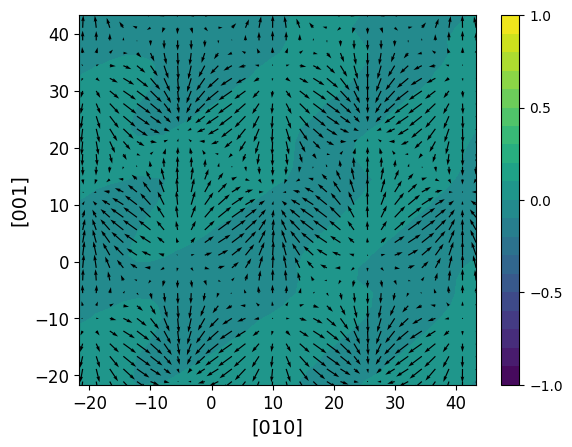

'max error = (array([15]), array([38])), min error = 0.00030235956496578627'

In [ ]:
Plot_Spins(output,1,np.pi/4,0,0)

In [ ]:
U,V,W = np.meshgrid(np.linspace(4.7, 4.9, 10),
                  np.linspace(4.7, 4.9, 10),
                  np.linspace(4.7, 4.9, 10))

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "colab"

In [ ]:
Th, Ph = np.meshgrid(np.linspace(0,np.pi,10), np.linspace(0,2*np.pi,10))
x = 0.5*np.sin(Th)*np.cos(Ph)
y = 0.5*np.sin(Th)*np.sin(Ph)
z = 0.5*np.cos(Th)

xf = x.flatten()
yf = y.flatten()
zf = z.flatten()

#16.5/np.sqrt(2),16.5/np.sqrt(2),-10.0

Sx, Sy, Sz = Spin2D_4q(output3q1,U[-1,-4,-5] + xf, V[-1,-4,-5] + yf, W[-1,-4,-5] + zf,2,0,0)
"""color_scalar = Sz.flatten()
fig = plt.figure(figsize = (9,9))
ax = fig.add_subplot(111, projection='3d')
q = ax.quiver(x, y, z, Sx, Sy, Sz,length=0.8,normalize=False,cmap="coolwarm",clim=(-1, 1),array = color_scalar)

ax.view_init(elev= 0, azim=np.pi/2)

cbar = fig.colorbar(q, ax=ax, shrink=0.7)
cbar.set_label('z')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.tight_layout()
plt.show()"""
fig = go.Figure(data=go.Cone(
    x=xf,
    y=yf,
    z=zf,
    u=Sx.flatten(),
    v=Sy.flatten(),
    w=Sz.flatten(),
    sizemode="absolute",
    sizeref= 0.3,
    anchor="tip"))

fig.update_layout(
      scene=dict(aspectmode = "data"), font = dict(size = 17))

fig.show()

In [ ]:
from matplotlib.ticker import MultipleLocator
Th, Ph = np.meshgrid(np.linspace(0,np.pi,10), np.linspace(0,2*np.pi,10))
x = 0.9*np.sin(Th)*np.cos(Ph)
y = 0.9*np.sin(Th)*np.sin(Ph)
z = 0.9*np.cos(Th)

xf = x.flatten()
yf = y.flatten()
zf = z.flatten()

#16.5/np.sqrt(2),16.5/np.sqrt(2),-10.0

Sx, Sy, Sz = Spin2D_4q(output,-7.320964850722758 + xf, 7.320964850722758 + yf,12.106365712816377 + zf,1,0,0)
"""color_scalar = Sz.flatten()
fig = plt.figure(figsize = (9,9))
ax = fig.add_subplot(111, projection='3d')
q = ax.quiver(x, y, z, Sx, Sy, Sz,length=0.8,normalize=False,cmap="coolwarm",clim=(-1, 1),array = color_scalar)

ax.view_init(elev= 0, azim=np.pi/2)

cbar = fig.colorbar(q, ax=ax, shrink=0.7)
cbar.set_label('z')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.tight_layout()
plt.show()"""
fig = go.Figure(data=go.Cone(
    x=xf,
    y=yf,
    z=zf,
    u=Sx.flatten(),
    v=Sy.flatten(),
    w=Sz.flatten(),
    sizemode="absolute",
    sizeref= 0.03,
    anchor="tip"))

fig.update_layout(
      scene=dict(aspectmode = "data", xaxis = dict(nticks = 3), yaxis = dict(nticks = 3), zaxis = dict(nticks = 3)), font = dict(size = 17))

fig.show()

In [ ]:
X, Y, Z = np.meshgrid(np.linspace(-2*np.pi/abs(output3q1[0]), 2*np.pi/abs(output3q1[0]), 7),
                      np.linspace(-2*np.pi/abs(output3q1[0]), 2*np.pi/abs(output3q1[0]), 7),
                      np.linspace(-2*np.pi/abs(output3q1[0]), 2*np.pi/abs(output3q1[0]), 7))

Xf = X.flatten()
Yf = Y.flatten()
Zf = Z.flatten()

Sx, Sy, Sz = Spin2D_4q(output3q1,X, Y, Z,nmax, 0,0)

fig = go.Figure(data=go.Cone(
    x=Xf,
    y=Yf,
    z=Zf,
    u=Sx.flatten(),
    v=Sy.flatten(),
    w=Sz.flatten(),
    sizemode="absolute",
    sizeref= 0.4,
    anchor="tip"))

fig.update_layout(
      scene=dict(aspectmode = "data"), font = dict(size = 15))

fig.show()

In [ ]:
x,y,z = symbols("x y z")
Mvec = np.array(Spin2D_4qsym(output3q1, x, y, z, 2, 0, -np.pi/4))
Mderx = []
Mdery = []
for i in range(len(Mvec)):
  Mderx.append(diff(Mvec[i],x))
  Mdery.append(diff(Mvec[i],y))
topchden = np.dot(Mvec,np.cross(np.array(Mderx),np.array(Mdery)))
topq = lambdify([x,y,z],topchden)